<a href="https://colab.research.google.com/github/stefanogiagu/corso_AI_2026/blob/main/ReadGraph_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Download Dataset
Si utilizza il codice in preso dal github del corso per scaricare il dataset nel corretto formato

In [123]:
!pip install torch_geometric

In [124]:
print('Downloading datasets')

!rm -rf g11.col
!wget https://raw.githubusercontent.com/stefanogiagu/corso_AI_2026/main/grafi/g11.col

!rm -rf g17.col
!wget https://raw.githubusercontent.com/stefanogiagu/corso_AI_2026/main/grafi/g17.col

print('Done')

--2026-05-28 11:49:18--  https://raw.githubusercontent.com/stefanogiagu/corso_AI_2026/main/grafi/g11.col
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2504 (2.4K) [text/plain]
Saving to: ‘g11.col’

g11.col             100%[===================>]   2.45K  --.-KB/s    in 0s      

2026-05-28 11:49:18 (54.5 MB/s) - ‘g11.col’ saved [2504/2504]

--2026-05-28 11:49:18--  https://raw.githubusercontent.com/stefanogiagu/corso_AI_2026/main/grafi/g17.col
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 35514 (35K) [text/plain]
Saving to: ‘g1

In [125]:
from pathlib import Path
from typing import Optional, Tuple, List, Dict, Union
import urllib.request

import torch
from torch_geometric.data import Data


def read_dimacs_col(
    path: Union[str, Path],
    make_undirected: bool = True,
    remove_self_loops: bool = True,
    dtype: torch.dtype = torch.float32,
) -> Data:
    """
    Read a graph coloring instance in DIMACS .col format and convert it
    to a PyTorch Geometric Data object.

    Expected DIMACS format:
        c comment lines
        p edge <num_nodes> <num_edges>
        e <u> <v>

    DIMACS nodes are usually 1-indexed.
    PyTorch Geometric expects 0-indexed node indices.

    Parameters
    ----------
    path:
        Path to the .col file.
    make_undirected:
        If True, each edge (u, v) is stored as both (u, v) and (v, u)
        in edge_index, as commonly expected by PyG message passing layers.
    remove_self_loops:
        If True, discard edges of the form (u, u).
    dtype:
        dtype for the default node features.

    Returns
    -------
    data:
        torch_geometric.data.Data object with fields:
            x: dummy node features, shape [num_nodes, 1]
            edge_index: graph connectivity, shape [2, num_edges_pyg]
            num_nodes: number of nodes
            name: file stem
            num_edges_dimacs: number of undirected edges declared/read
    """

    path = Path(path)

    if path.suffix == ".b" or path.name.endswith(".col.b"):
        raise ValueError(
            f"{path.name} appears to be a binary .col.b file. "
            "This parser only supports standard text DIMACS .col files."
        )

    num_nodes: Optional[int] = None
    declared_num_edges: Optional[int] = None
    edges: List[Tuple[int, int]] = []

    with path.open("r", encoding="utf-8", errors="ignore") as f:
        for line_number, line in enumerate(f, start=1):
            line = line.strip()

            if not line:
                continue

            parts = line.split()

            # Comment line
            if parts[0] == "c":
                continue

            # Problem line: p edge n m
            if parts[0] == "p":
                if len(parts) < 4:
                    raise ValueError(
                        f"Malformed problem line at line {line_number}: {line}"
                    )

                problem_type = parts[1]
                if problem_type not in {"edge", "col"}:
                    # Most coloring instances use 'p edge n m'
                    # but we allow other variants with a warning-like behavior.
                    pass

                num_nodes = int(parts[2])
                declared_num_edges = int(parts[3])
                continue

            # Edge line: e u v
            if parts[0] == "e":
                if len(parts) < 3:
                    raise ValueError(
                        f"Malformed edge line at line {line_number}: {line}"
                    )

                # Convert from 1-indexed DIMACS to 0-indexed PyG.
                u = int(parts[1]) - 1
                v = int(parts[2]) - 1

                if remove_self_loops and u == v:
                    continue

                edges.append((u, v))
                continue

            # Ignore unknown line types, but this can be made stricter if desired.
            # raise ValueError(f"Unknown line type at line {line_number}: {line}")

    if num_nodes is None:
        raise ValueError(f"No problem line 'p edge n m' found in {path}")

    if len(edges) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long)
    else:
        # Remove duplicate undirected edges robustly.
        # DIMACS stores undirected edges; we canonicalize as (min, max).
        unique_edges = set()
        for u, v in edges:
            if u < 0 or v < 0 or u >= num_nodes or v >= num_nodes:
                raise ValueError(
                    f"Edge ({u + 1}, {v + 1}) out of bounds for graph "
                    f"with {num_nodes} nodes in file {path}"
                )

            a, b = min(u, v), max(u, v)
            unique_edges.add((a, b))

        edge_list = sorted(unique_edges)

        if make_undirected:
            pyg_edges = edge_list + [(v, u) for u, v in edge_list]
        else:
            pyg_edges = edge_list

        edge_index = torch.tensor(pyg_edges, dtype=torch.long).t().contiguous()

    # Dummy node features.
    # For graph coloring, the learnable node embeddings can be created later
    # inside the model, but PyG Data objects usually contain x.
    x = torch.ones((num_nodes, 1), dtype=dtype)

    data = Data(
        x=x,
        edge_index=edge_index,
        num_nodes=num_nodes,
    )

    data.name = path.stem.replace(".col", "")
    data.num_edges_dimacs = len(edges)
    data.num_edges_unique = edge_index.size(1) // 2 if make_undirected else edge_index.size(1)
    data.declared_num_edges = declared_num_edges

    if declared_num_edges is not None and declared_num_edges != len(edges):
        data.edge_count_warning = (
            f"Declared {declared_num_edges} edges, read {len(edges)} edge lines."
        )
    else:
        data.edge_count_warning = None

    return data

In [126]:
data11 = read_dimacs_col("g11.col")
data17 = read_dimacs_col("g17.col")

print(data11)
print("Name:", data11.name)
print("Number of nodes:", data11.num_nodes)
print("DIMACS edges:", data11.num_edges_unique)
print("PyG edge_index shape:", data11.edge_index.shape)
print('\n')
print(data17)
print("Name:", data17.name)
print("Number of nodes:", data17.num_nodes)
print("DIMACS edges:", data17.num_edges_unique)
print("PyG edge_index shape:", data17.edge_index.shape)

Data(x=[25, 1], edge_index=[2, 320], num_nodes=25, name='g11', num_edges_dimacs=320, num_edges_unique=160, declared_num_edges=320)
Name: g11
Number of nodes: 25
DIMACS edges: 160
PyG edge_index shape: torch.Size([2, 320])


Data(x=[128, 1], edge_index=[2, 4226], num_nodes=128, name='g17', num_edges_dimacs=4226, num_edges_unique=2113, declared_num_edges=4226)
Name: g17
Number of nodes: 128
DIMACS edges: 2113
PyG edge_index shape: torch.Size([2, 4226])


Visualizzazione dei grafi

Text(0.5, 1.0, 'G17')

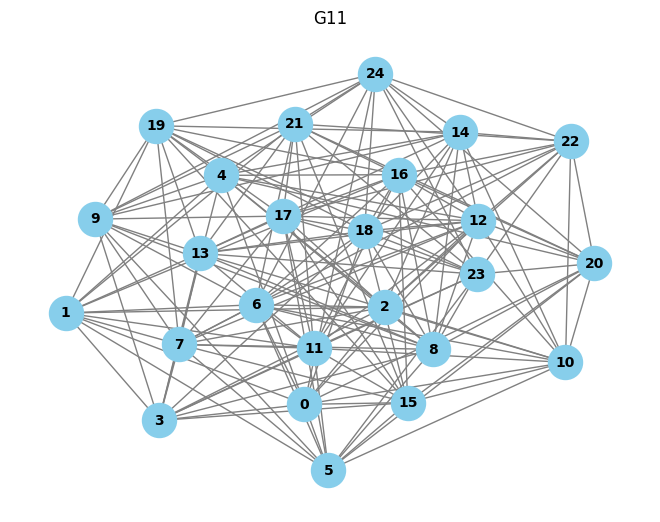

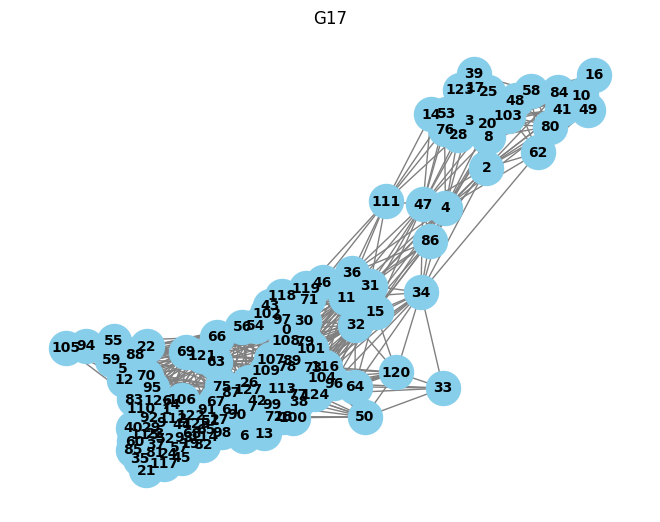

In [127]:
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx

G = to_networkx(data11, to_undirected=True)
pos = nx.spring_layout(G)
plt.figure()
nx.draw(
    G, 
    pos, 
    with_labels=True, 
    node_color='skyblue', 
    edge_color='gray', 
    node_size=600, 
    font_size=10, 
    font_weight='bold'
)
plt.title('G11')

G = to_networkx(data17, to_undirected=True)
pos = nx.spring_layout(G)
plt.figure()
nx.draw(
    G, 
    pos, 
    with_labels=True, 
    node_color='skyblue', 
    edge_color='gray', 
    node_size=600, 
    font_size=10, 
    font_weight='bold'
)
plt.title('G17')



# Architettura del modello

In [128]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class ColoraGrafo(nn.Module):
    def __init__(self, c=5, hidden1=64):
        super().__init__()

        self.conv1 = SAGEConv(1, hidden1)
        self.conv2 = SAGEConv(hidden1, hidden1)
        self.conv3 = SAGEConv(hidden1, hidden1)

        self.fc1 = nn.Linear(hidden1, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden1)
        self.fc3 = nn.Linear(hidden1, c)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        # message passing con relu tra i layer
        x = F.relu(self.conv1(x, edge_index))
        #x = F.relu(self.conv2(x, edge_index))
        #x = F.relu(self.conv3(x, edge_index))

        # layer finale lineare con softmax
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        x = F.softmax(x, dim=-1)

        return x

In [129]:
# aggiungo una funzione che aumenti la varianza iniziale dei pesi
def custom_weight_init(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0.0, std=0.3)
        
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
            
    elif hasattr(m, 'weight'): 
        nn.init.normal_(m.weight, mean=0.0, std=0.3)

In [130]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else print('Marta puzzi non hai messo le gpu')
print('Using',device, 'device')

model = ColoraGrafo().to(device)
print(model)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Numero di parametri trainabili:", num_params)

Using cuda device
ColoraGrafo(
  (conv1): SAGEConv(1, 64, aggr=mean)
  (conv2): SAGEConv(64, 64, aggr=mean)
  (conv3): SAGEConv(64, 64, aggr=mean)
  (fc1): Linear(in_features=64, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=5, bias=True)
)
Numero di parametri trainabili: 25349


# Loss, metriche e ottimizzatore

In [131]:
model17 = ColoraGrafo(c=20).to(device)

#model11.apply(custom_weight_init)
#model17.apply(custom_weight_init)

import torch.optim as optim
optimizer17 = optim.Adam(model17.parameters(), lr = 0.02)



# definizione della loss
def potts_energy_differentiable(pred, edge_index):
    """
    colori -> [num_nodes, c]
    calcolo l'energia di potts in formato differenziabile
    """
    i, j = edge_index

    edge_energy = (pred[i]*pred[j]).sum(dim=-1)
    return edge_energy.sum()

# come metrica utilizziamo il numero di conflitti
def pott_energy_normal(pred, edge_index):
    """
    Come prima ma con argmax prima
    """

    i, j = edge_index
    colori = pred.argmax(dim=-1)
    edge_energy = (colori[i] == colori[j]).int()
    return edge_energy.sum()
    
    

In [132]:
# proviamo a vedere che tutto funzioni

#model.apply(custom_weight_init)
data11.x = torch.randn(data11.num_nodes, 1)
data11 = data11.to(device)


pred = model(data11)

loss = potts_energy_differentiable(pred, data11.edge_index)
conflitti = pott_energy_normal(pred, data11.edge_index)

print('Loss: ', loss.item())
print('N conflitti: ', conflitti.item())

Loss:  64.47103881835938
N conflitti:  320


# Addestramento

**Addestro prima il grafo 11**

In [148]:
num_epochs = 1000
data11.x = torch.randn(data11.num_nodes, 1)
data = data11.to(device)

model11 = ColoraGrafo(c=8).to(device)
optimizer11 = optim.Adam(model11.parameters(), lr = 0.001)

train_curve = []
conflicts_curve = []

for epoch in range(num_epochs):
    model11.train()
    
    # forward pass
    output = model11(data)
    loss = potts_energy_differentiable(output, data.edge_index)

    # backward pass and backpropagation
    optimizer11.zero_grad()
    loss.backward()
    optimizer11.step()

    # calcolo i conflitti 
    #model11.eval()
    conflicts = pott_energy_normal(output, data.edge_index)

    # salvo loss e conflitti
    train_curve.append(loss.cpu().detach().numpy())
    conflicts_curve.append(conflicts.cpu().detach().numpy())

    print(f"Epoch {epoch+1}, Loss: {loss:.4f}, Conflicts: {conflicts:.4f}")




Epoch 1, Loss: 40.2881, Conflicts: 264.0000
Epoch 2, Loss: 40.2040, Conflicts: 224.0000
Epoch 3, Loss: 40.1391, Conflicts: 148.0000
Epoch 4, Loss: 40.0891, Conflicts: 122.0000
Epoch 5, Loss: 40.0511, Conflicts: 138.0000
Epoch 6, Loss: 40.0244, Conflicts: 116.0000
Epoch 7, Loss: 40.0082, Conflicts: 82.0000
Epoch 8, Loss: 40.0016, Conflicts: 78.0000
Epoch 9, Loss: 40.0032, Conflicts: 96.0000
Epoch 10, Loss: 40.0098, Conflicts: 142.0000
Epoch 11, Loss: 40.0166, Conflicts: 146.0000
Epoch 12, Loss: 40.0205, Conflicts: 146.0000
Epoch 13, Loss: 40.0205, Conflicts: 146.0000
Epoch 14, Loss: 40.0177, Conflicts: 146.0000
Epoch 15, Loss: 40.0135, Conflicts: 146.0000
Epoch 16, Loss: 40.0092, Conflicts: 132.0000
Epoch 17, Loss: 40.0054, Conflicts: 128.0000
Epoch 18, Loss: 40.0023, Conflicts: 114.0000
Epoch 19, Loss: 40.0002, Conflicts: 70.0000
Epoch 20, Loss: 39.9989, Conflicts: 76.0000
Epoch 21, Loss: 39.9984, Conflicts: 56.0000
Epoch 22, Loss: 39.9985, Conflicts: 60.0000
Epoch 23, Loss: 39.9990, C

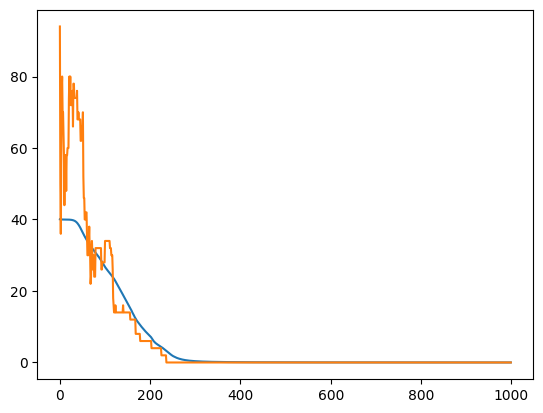

In [134]:
plt.figure()
plt.plot(train_curve)
plt.plot(conflicts_curve)

In [ ]:
# preparo le funzioni per fare più allenamenti
import numpy as np
def oneTrain(data, c, num_epochs=400):
    data.x = torch.randn(data.num_nodes, 1)
    data = data.to(device)

    model = ColoraGrafo(c=c).to(device)
    optimizer = optim.Adam(model.parameters(), lr = 0.001)
    model.train()
    for epoch in range(num_epochs):
    
        # forward pass
        output = model(data)
        loss = potts_energy_differentiable(output, data.edge_index)

        # backward pass and backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # calcolo i conflitti 
        #model11.eval()
        conflicts = pott_energy_normal(output, data.edge_index)

        # salvo loss e conflitti
        #print(f"Epoch {epoch+1}, Loss: {loss:.4f}, Conflicts: {conflicts:.4f}")

    return loss.cpu().detach().numpy(), conflicts.cpu().detach().numpy()


def train_ensemble(data, c, num_sim=10):
    conflitti = []
    for i in range(num_sim):
        temp, temp1 = oneTrain(data, c)
        conflitti.append(temp1)
    conflitti = np.array([conflitti])
    return conflitti.mean(), conflitti.std()



In [160]:
# adesso i loop di allenamenti
cmin = 5
cmax = 16
conflitti_medie = []
conflitti_std = []
for c in range(cmin, cmax):
    media, dev = train_ensemble(data11, c)
    conflitti_medie.append(media)
    conflitti_std.append(dev)
    print(c, media, dev)


5 25.2 6.013318551349163
6 19.8 4.237924020083418
7 11.8 2.0880613017821097
8 8.4 3.8781438859330635
9 5.4 4.565084884205331
10 5.4 4.476605857119878
11 3.2 4.664761515876241
12 1.8 4.770744176750625
13 1.6 2.3323807579381204
14 0.8 0.9797958971132712
15 0.4 1.2000000000000002


'\nCome commento sembra che quando si  raggiunto il numero cromatico le fluttuazioni diminuiscano proprio perché esistendo un minimo si è in grado di trovarlo, mentre se non esiste esistono tanti minimi locali\n'

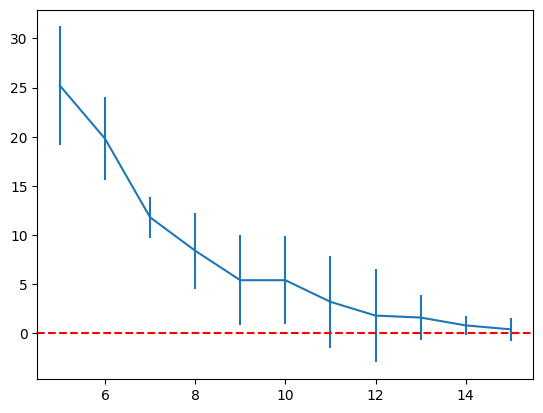

In [164]:
plt.figure()
plt.errorbar(range(cmin, cmax), conflitti_medie, yerr=conflitti_std)
plt.axhline(0, color='red', linestyle='--')

"""
Come commento sembra che quando si  raggiunto il numero cromatico le fluttuazioni diminuiscano proprio perché esistendo un minimo si è in grado di trovarlo, mentre se non esiste esistono tanti minimi locali
"""